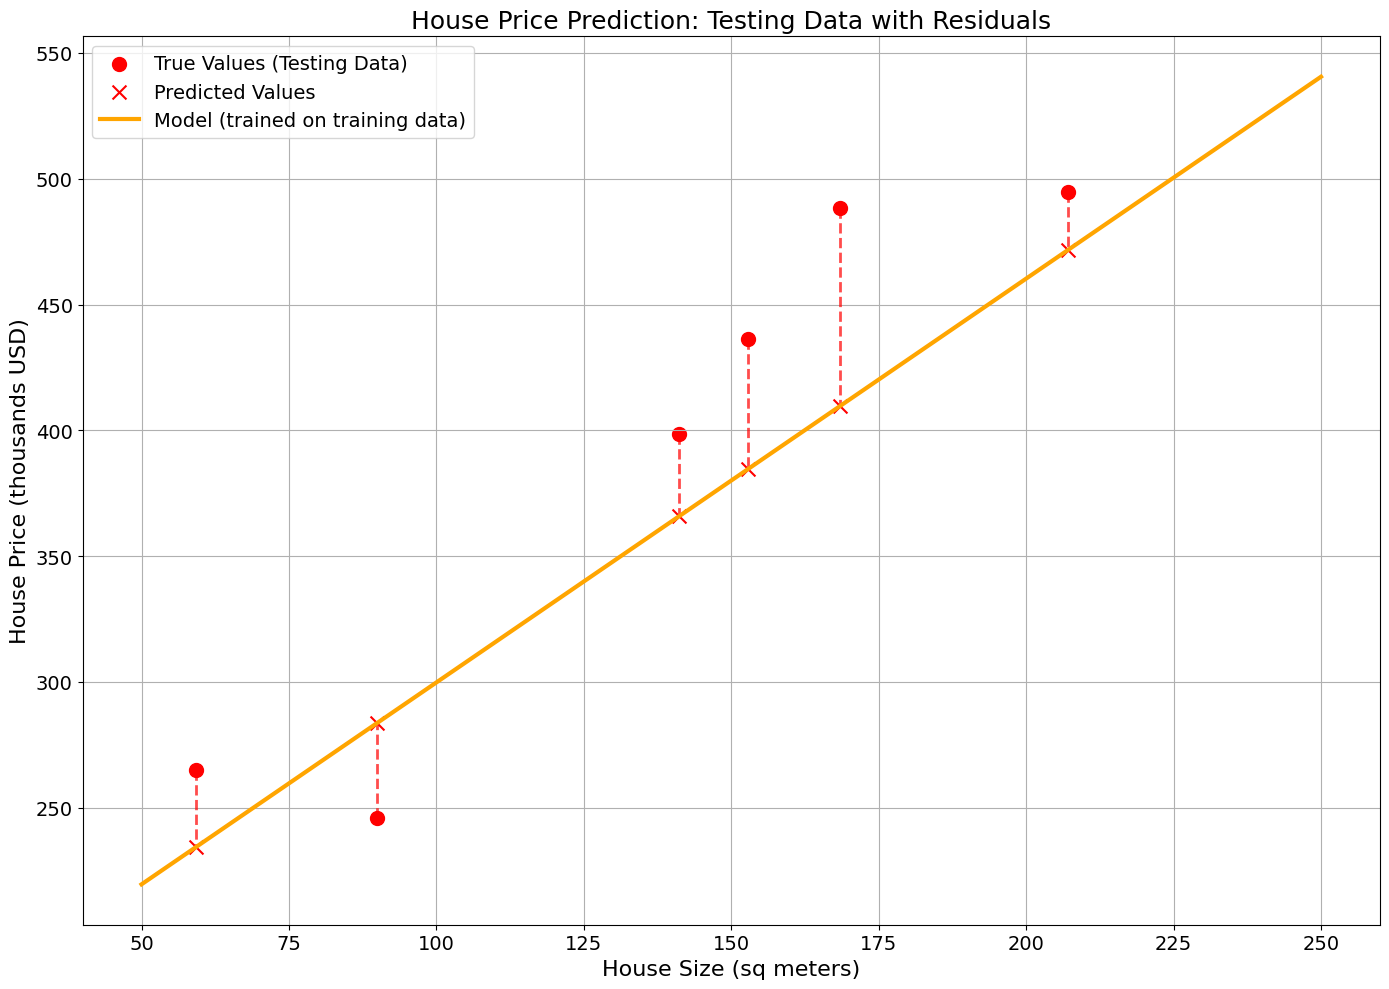

Number of testing samples: 6
Mean Absolute Error on testing data: 42.43 thousand USD
Root Mean Squared Error on testing data: 46.25 thousand USD


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate less data
n_samples = 30  # Reduced from 100
x = np.random.uniform(50, 250, n_samples)  # House sizes between 50 and 250 sq meters
y = 100 + 2 * x + np.random.normal(0, 50, n_samples)  # Price in thousands of USD

# Split data into training and testing sets
split = int(0.8 * n_samples)
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]

# Fit a linear model using only training data
z = np.polyfit(x_train, y_train, 1)
p = np.poly1d(z)

# Calculate predicted values for testing data
y_pred = p(x_test)

# Create the plot
plt.figure(figsize=(14, 10))

# Plot the testing data points
plt.scatter(x_test, y_test, color='red', marker='o', s=100, label='True Values (Testing Data)')

# Plot the predicted values
plt.scatter(x_test, y_pred, color='red', marker='x', s=100, label='Predicted Values')

# Plot the residual lines
for i in range(len(x_test)):
    plt.plot([x_test[i], x_test[i]], [y_test[i], y_pred[i]], color='red', linestyle='--', linewidth=2, alpha=0.7)

# Plot the model line
x_line = np.linspace(50, 250, 100)
plt.plot(x_line, p(x_line), color='orange', linestyle='-', linewidth=3, label='Model (trained on training data)')

plt.xlabel('House Size (sq meters)', fontsize=16)
plt.ylabel('House Price (thousands USD)', fontsize=16)
plt.title('House Price Prediction: Testing Data with Residuals', fontsize=18)
plt.legend(fontsize=14)
plt.grid(True)

# Increase tick label size
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

# Calculate and print error metrics
residuals = y_test - y_pred
mae = np.mean(np.abs(residuals))
rmse = np.sqrt(np.mean(residuals**2))

print(f"Number of testing samples: {len(x_test)}")
print(f"Mean Absolute Error on testing data: {mae:.2f} thousand USD")
print(f"Root Mean Squared Error on testing data: {rmse:.2f} thousand USD")

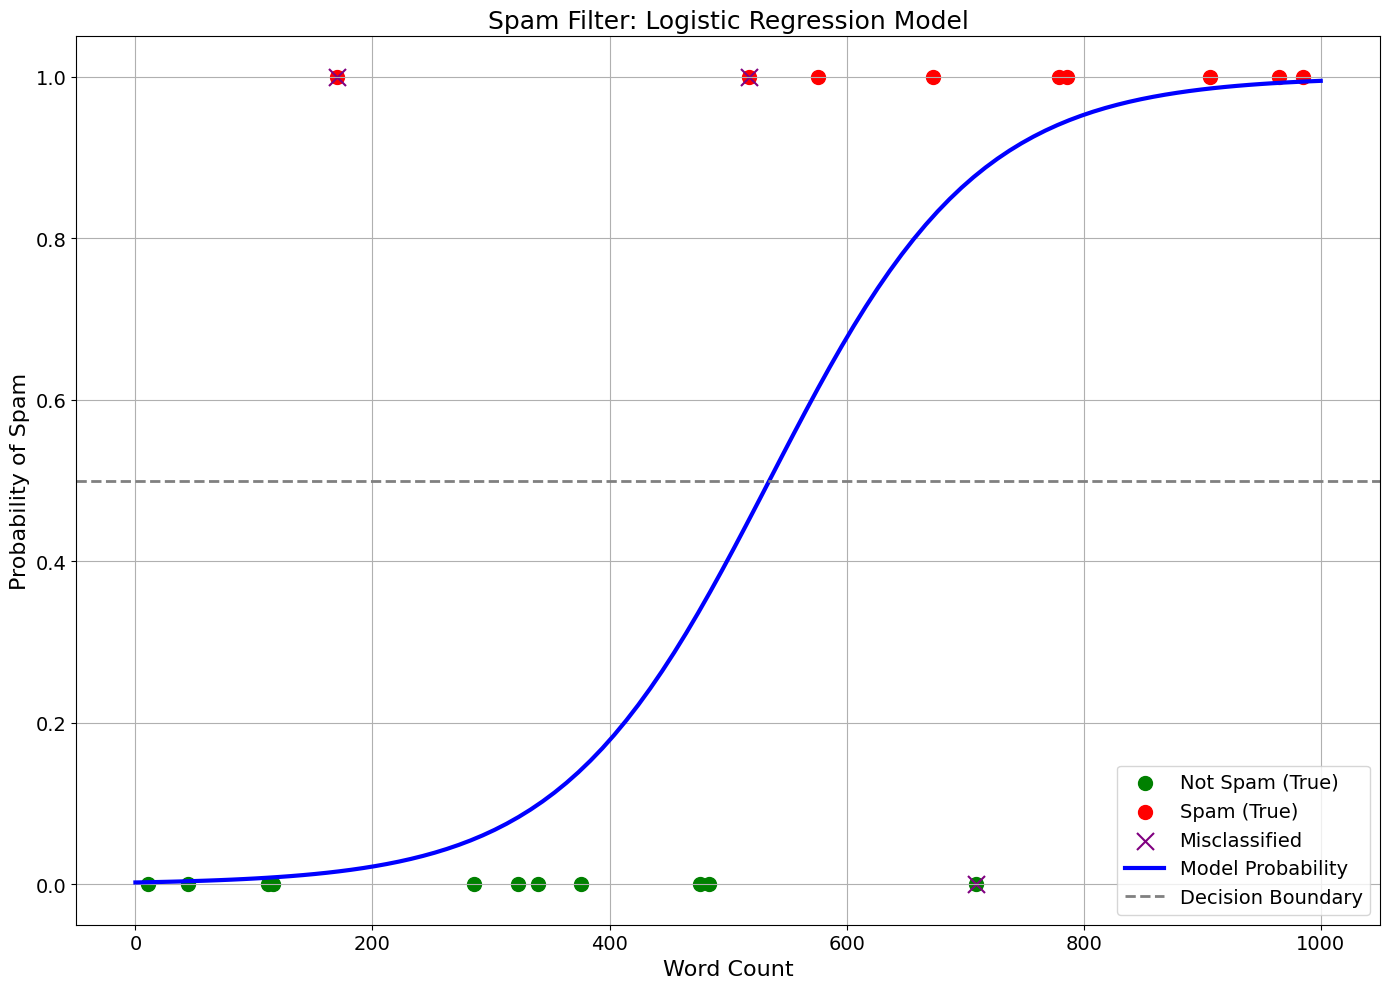

Confusion Matrix:
[[10  1]
 [ 2  7]]

Confusion Matrix Interpretation:
True Negatives: 10
False Positives: 1
False Negatives: 2
True Positives: 7


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Set random seed for reproducibility
np.random.seed(42)

# Generate data
n_samples = 100
x = np.random.randint(10, 1000, n_samples)  # Word counts between 10 and 1000
y = (x > 500).astype(int)  # 1 if word count > 500, 0 otherwise

# Add some noise to create misclassifications
noise = np.random.random(n_samples) < 0.1  # 10% noise
y = np.logical_xor(y, noise).astype(int)

# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Reshape x for scikit-learn
x_train = x_train.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)

# Fit logistic regression model
model = LogisticRegression()
model.fit(x_train, y_train)

# Predict on test data
y_pred = model.predict(x_test)

# Create the plot
plt.figure(figsize=(14, 10))

# Plot the testing data points
plt.scatter(x_test[y_test == 0], y_test[y_test == 0], color='green', marker='o', s=100, label='Not Spam (True)')
plt.scatter(x_test[y_test == 1], y_test[y_test == 1], color='red', marker='o', s=100, label='Spam (True)')

# Plot the misclassified points
misclassified = y_test != y_pred
plt.scatter(x_test[misclassified], y_test[misclassified], color='purple', marker='x', s=150, label='Misclassified')

# Plot the decision boundary
x_range = np.linspace(0, 1000, 100).reshape(-1, 1)
y_proba = model.predict_proba(x_range)[:, 1]
plt.plot(x_range, y_proba, color='blue', linestyle='-', linewidth=3, label='Model Probability')

plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=2, label='Decision Boundary')

plt.xlabel('Word Count', fontsize=16)
plt.ylabel('Probability of Spam', fontsize=16)
plt.title('Spam Filter: Logistic Regression Model', fontsize=18)
plt.legend(fontsize=14)
plt.grid(True)

# Increase tick label size
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

# Calculate and print confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("\nConfusion Matrix Interpretation:")
print(f"True Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

In [3]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the California Housing Prices dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(df.head())

# Split the data into features (X) and target variable (y)
X = df.drop(columns=['target'])
y = df['target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

# Print the evaluation metrics
print("Mean Absolute Error (MAE)", mae)
print("Mean Squared Error (MSE):", mse)
print("R-squared (R²)", r_squared)
print("Root Mean Squared Error (RMSE)", rmse)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  
Mean Absolute Error (MAE) 0.5332001304956553
Mean Squared Error (MSE): 0.5558915986952444
R-squared (R²) 0.5757877060324508
Root Mean Squared Error (RMSE) 0.7455813830127764
